### Validation of Segmentation Methods

- choose a representative that is in the middle of the stack with typical signal density/quality, not the cleanest or the noisiest outlier
- if possible get more than one person to label the same slice independently so i can compute inter-rater agreement (human bias)
- I could use that to compute the signal to noise ratio


- I chose slide 160 and send the preprocessed version to Kaisla 
- Kaisla has a labelling setup wich she used to label the connexin areas as dots 

In [52]:
# imports

# load packages 
from pathlib import Path
BASE_DIR = Path.cwd().parent
import stackview
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(str(BASE_DIR / 'src'))
# python files
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
# from cellpose import models, io
# from scipy import ndimage

In [53]:
segmented_mask_21_15 = io.imread(BASE_DIR / 'data/segmented/binary_sauvola2d_w21_k0_15.tiff')
segmented_mask_21_15 = segmented_mask_21_15[100] #get only plane 160 -> is now 100 because it was precut in segmentation
mask_dots = io.imread(BASE_DIR / 'data/manual_annotations/small_deconvolved_3d_plane_160_labels_pixels.tif')
mask_dots= mask_dots[:, 26:996] # only 2D plane 160
mask_areas = io.imread(BASE_DIR / 'data/manual_annotations/small_deconvolved_3d_plane_160_labels.tif')
mask_areas= mask_areas[:, 26:996] # only 2D plane 160
preprocessed_image = io.imread(str(BASE_DIR / 'data/preprocessed/background_removed_and_deconvolved_img.tiff'))
preprocessed_image= preprocessed_image[160, :, 23:999] 

In [54]:
print(mask_dots.shape)
print(mask_areas.shape)
print(preprocessed_image.shape)
print(segmented_mask_21_15.shape)

(2033, 970)
(2033, 970)
(2033, 976)
(2033, 976)


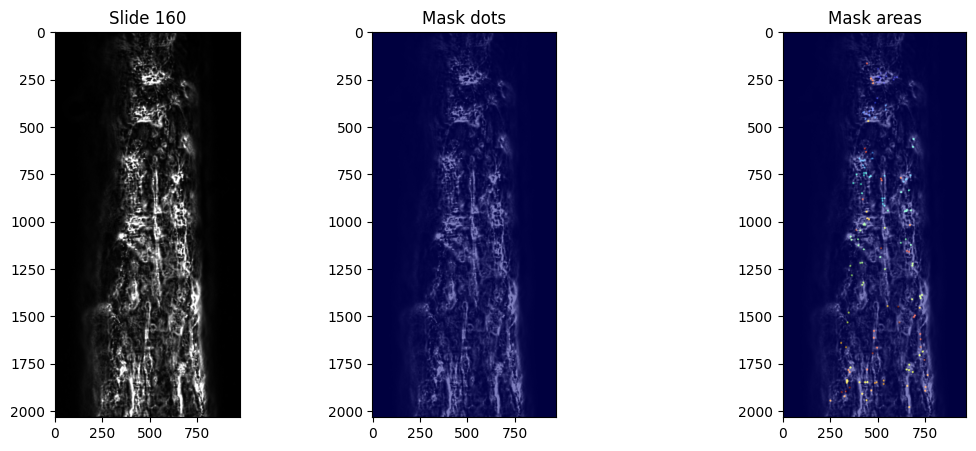

In [55]:
# plot slide 160, 250 and 360 next to each other 
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(preprocessed_image, cmap='gray', vmin=np.percentile(preprocessed_image, 1), vmax=np.percentile(preprocessed_image, 99))
plt.title('Slide 160')
# plot the image and the mask on top of the cnx image 

plt.subplot(1, 3, 2)
plt.imshow(preprocessed_image, cmap='gray', vmin=np.percentile(preprocessed_image, 1), vmax=np.percentile(preprocessed_image, 99))
plt.imshow(mask_dots, cmap='jet', alpha=0.5)
plt.title('Mask dots')
plt.subplot(1, 3, 3)
plt.imshow(preprocessed_image, cmap='gray', vmin=np.percentile(preprocessed_image, 1), vmax=np.percentile(preprocessed_image, 99))
plt.imshow(mask_areas, cmap='jet', alpha=0.5)
plt.title('Mask areas')
plt.show()

## Allow a z tolerance -> didn't do that

Reason is that the algorithm is quite strict to avoid catching noise and therefore very dim regions may not be segmented in a lighter plane but in one before or after 

In [56]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.ndimage import binary_fill_holes


def evaluate_segmentation(mask_dots, segmented_mask, slice_idx, z_margin=0, 
                            label="segmentation", fill_holes=True):
    """
    Evaluate a single segmented_mask against manual dot annotations for one slice.
    
    Parameters
    ----------
    mask_dots       : 2D binary array of manual dot annotations (for this slice)
    segmented_mask  : 3D binary array, full stack
    slice_idx       : int, index of the annotated slice
    z_margin        : int, number of slices to include on each side (z-slab projection)
    label           : str, name for this segmentation setting (used in output table)
    fill_holes      : bool, whether to fill holes in regions before containment test
                      (avoids ring/donut-shaped regions causing false FN/FP, see earlier discussion)
    
    Returns
    -------
    dict of metrics and intermediate results (for optional plotting)
    """
    # ---- Step 1: extract manual dot centroids ----
    labeled_dots, num_dots = ndimage.label(mask_dots)
    manual_points_yx = np.array(
        ndimage.center_of_mass(mask_dots, labeled_dots, range(1, num_dots + 1))
    )

    # ---- Step 2: get the 2D plane to evaluate ----
    if segmented_mask.ndim == 2:
        # already a single 2D plane (the annotated slice) -> use it directly
        slab_proj = segmented_mask.astype(bool)
        z_min, z_max = slice_idx, slice_idx + 1
    else:
        # project segmented_mask +/- z_margin slices into 2D
        z_min = max(0, slice_idx - z_margin)
        z_max = min(segmented_mask.shape[0], slice_idx + z_margin + 1)
        slab_proj = np.any(segmented_mask[z_min:z_max], axis=0)

    if fill_holes:
        slab_proj = binary_fill_holes(slab_proj)

    labeled_regions, num_regions = ndimage.label(slab_proj)

    # ---- Step 3: containment check (with tolerance) ----
    tolerance_px = 2  # adjust based on plaque size / density

    matched_labels = set()
    fn_points = []

    for (y, x) in manual_points_yx:
        y_r, x_r = int(round(y)), int(round(x))
        y0, y1 = max(0, y_r - tolerance_px), y_r + tolerance_px + 1
        x0, x1 = max(0, x_r - tolerance_px), x_r + tolerance_px + 1

        local_patch = labeled_regions[y0:y1, x0:x1]
        labels_present = np.unique(local_patch)
        labels_present = labels_present[labels_present != 0]

        if len(labels_present) > 0:
            matched_labels.update(labels_present)  # all touched regions count as matched
            # if multiple regions touch one dot, they're all considered "found" —
            # avoids double-penalizing a dot sitting in a gap between two close blobs
        else:
            fn_points.append((y, x))

    TP = num_dots - len(fn_points)
    FN = len(fn_points)
    FP = num_regions - len(matched_labels)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "label": label,
        "slice_idx": slice_idx,
        "z_margin": z_margin,
        "z_range": f"[{z_min}:{z_max}]",
        "num_manual_dots": num_dots,
        "num_regions": num_regions,
        "TP": TP, "FP": FP, "FN": FN,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1_score": round(f1, 3),
        # kept for optional downstream plotting, not shown in the summary table
        "_manual_points_yx": manual_points_yx,
        "_fn_points": fn_points,
        "_matched_labels": matched_labels,
        "_labeled_regions": labeled_regions,
        "_slab_proj": slab_proj,
    }


def compare_segmentations(mask_dots, segmented_masks_dict, slice_idx, z_margin=0, fill_holes=True):
    """
    Run evaluate_segmentation for multiple segmented masks and return a comparison table.
    
    Parameters
    ----------
    segmented_masks_dict : dict of {label: segmented_mask_3D_array}
                            e.g. {"window21_k0.1": mask_A, "window15_k0.1": mask_B}
    
    Returns
    -------
    df      : pandas DataFrame, summary comparison table
    results : dict of {label: full result dict}, for further plotting
    """
    results = {}
    rows = []

    for label, seg_mask in segmented_masks_dict.items():
        r = evaluate_segmentation(mask_dots, seg_mask, slice_idx, z_margin, label, fill_holes)
        results[label] = r
        rows.append({k: v for k, v in r.items() if not k.startswith("_")})

    df = pd.DataFrame(rows).set_index("label")
    return df, results

In [57]:
# validate ONLY the new segmentation (binary_sauvola2d_w21_k0_15) against the manual annotation
segmented_masks_dict = {
    "window21_k0.15": segmented_mask_21_15,
}

# segmented_mask_21_15 is already the single 2D plane 160 (extracted in the load cell),
# so slice_idx is only a label here and z_margin is unused.
df, results = compare_segmentations(
    mask_dots, segmented_masks_dict, slice_idx=160, z_margin=0, fill_holes=True
)

print(df)

                slice_idx  z_margin    z_range  num_manual_dots  num_regions  \
label                                                                          
window21_k0.15        160         0  [160:161]              172          522   

                 TP   FP  FN  precision  recall  f1_score  
label                                                      
window21_k0.15  155  387  17      0.286   0.901     0.434  


In [58]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage


def plot_comparison(original_cnx, results_dict, figsize_per_plot=(6, 6)):
    """
    Plot TP/FN/FP overlay for multiple segmentation results side by side.
    
    Parameters
    ----------
    results_dict : dict of {label: result_dict}, as returned by compare_segmentations
                    (or a subset you select from `results`)
    """
    n = len(results_dict)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_plot[0] * n, figsize_per_plot[1]))
    
    if n == 1:
        axes = [axes]  # keep iterable when only one plot

    for ax, (label, result) in zip(axes, results_dict.items()):
        slab_proj = result["_slab_proj"]
        labeled_regions = result["_labeled_regions"]
        fn_points = result["_fn_points"]
        manual_points_yx = result["_manual_points_yx"]
        matched_labels = result["_matched_labels"]
        num_regions = labeled_regions.max()

        ax.imshow(original_cnx, cmap='gray', vmax = 7000)

        # TP: manual dots inside a region -> green
        for (y, x) in manual_points_yx:
            if not any(np.allclose((y, x), fp) for fp in fn_points):
                ax.plot(x, y, 'o', color='lime', markersize=8, markerfacecolor='none', markeredgewidth=2)

        # FN: manual dots with no region -> yellow
        for (y, x) in fn_points:
            ax.plot(x, y, 'o', color='yellow', markersize=8, markerfacecolor='none', markeredgewidth=2)

        # FP: regions with no manual dot inside -> red X at centroid
        all_labels = set(range(1, num_regions + 1))
        fp_labels = list(all_labels - matched_labels)
        if fp_labels:
            fp_centroids = ndimage.center_of_mass(slab_proj, labeled_regions, fp_labels)
            for (y, x) in fp_centroids:
                ax.plot(x, y, 'rx', markersize=6, markeredgewidth=1.5)

        ax.set_title(
            f"{label}\nP={result['precision']:.3f}, R={result['recall']:.3f}, F1={result['f1_score']:.3f}\n"
            f"TP={result['TP']}, FP={result['FP']}, FN={result['FN']}"
        )

    plt.tight_layout()
    plt.show()

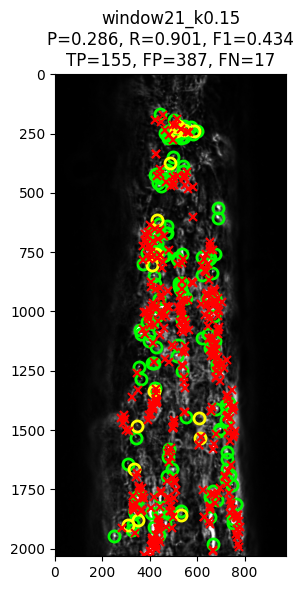

In [59]:
plot_comparison(original_cnx = preprocessed_image, results_dict = results)  # plots all entries in `results` side by side

# or select a subset
# plot_comparison({k: results[k] for k in ["A_window21_k0.2", "B_window15_k0.1"]})

In [60]:
def plot_window(original_cnx, result, row_range, col_range, ax=None):
    """
    Plot TP/FN/FP overlay cropped to a fixed window.
    
    Parameters
    ----------
    original_cnx : the original image array
    result     : a single result dict (as returned by evaluate_segmentation)
    row_range  : (row_min, row_max) tuple, e.g. (950, 1250)
    col_range  : (col_min, col_max) tuple, e.g. (350, 550)
    """
    slab_proj = result["_slab_proj"]
    labeled_regions = result["_labeled_regions"]
    fn_points = result["_fn_points"]
    manual_points_yx = result["_manual_points_yx"]
    matched_labels = result["_matched_labels"]
    num_regions = labeled_regions.max()

    r_min, r_max = row_range
    c_min, c_max = col_range
    crop = original_cnx[r_min:r_max, c_min:c_max]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(crop, cmap='gray', extent=[c_min, c_max, r_max, r_min], vmax = 10000)

    # ax.imshow(original_cnx[r_min:r_max, c_min:c_max], cmap='gray', vmax = 7000)

    for (y, x) in manual_points_yx:
        if c_min <= x <= c_max and r_min <= y <= r_max:
            is_fn = any(np.allclose((y, x), fp) for fp in fn_points)
            color = 'yellow' if is_fn else 'lime'
            ax.plot(x, y, 'o', color=color, markersize=10, markerfacecolor='none', markeredgewidth=2)

    all_labels = set(range(1, num_regions + 1))
    fp_labels = list(all_labels - matched_labels)
    if fp_labels:
        fp_centroids = ndimage.center_of_mass(slab_proj, labeled_regions, fp_labels)
        for (y, x) in fp_centroids:
            if c_min <= x <= c_max and r_min <= y <= r_max:
                ax.plot(x, y, 'rx', markersize=8, markeredgewidth=2)

    # ax.set_title(f"{result['label']} — [{r_min}:{r_max}, {c_min}:{c_max}]")
    ax.set_title(
        f"{result['label']}\nP={result['precision']:.3f}, R={result['recall']:.3f}, F1={result['f1_score']:.3f}\n"
        f"TP={result['TP']}, FP={result['FP']}, FN={result['FN']}"
    )

    if standalone:
        plt.show()

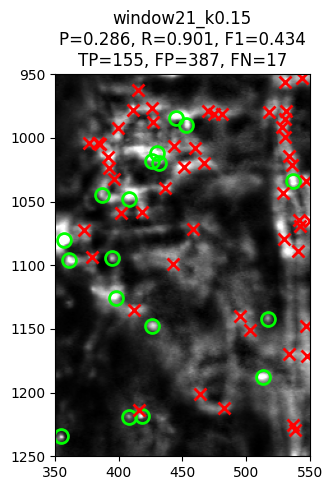

In [61]:
def plot_window_comparison(original_cnx, results_dict, row_range, col_range, figsize_per_plot=(5, 5)):
    n = len(results_dict)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_plot[0] * n, figsize_per_plot[1]))
    if n == 1:
        axes = [axes]
    for ax, (label, result) in zip(axes, results_dict.items()):
        plot_window(original_cnx, result, row_range, col_range, ax=ax)
    plt.tight_layout()
    plt.show()

plot_window_comparison(preprocessed_image, results, row_range=(950, 1250), col_range=(350, 550))

## Visually compare within a smaller area

In [39]:
# counting the seperate regions in binary segmented mask 
from skimage import measure

labeled_array = measure.label(segmented_mask_21_15)  # label the connected components in the binary mask
num_regions = labeled_array.max()  # or len(np.unique(labeled_array)) - 1
print("Number of separate areas for slide 160 in :")
print(f"segmented mask: {num_regions}")
print(f"manually labelled mask: {mask_dots.max()}")

# # Bonus: get region properties like area, centroid, bounding box, etc.
# props = measure.regionprops(labeled_array)
# for i, region in enumerate(props):
#     print(f"Region {i+1}: area={region.area}, centroid={region.centroid}")

Number of separate areas for slide 160 in :
segmented mask: 481
manually labelled mask: 172


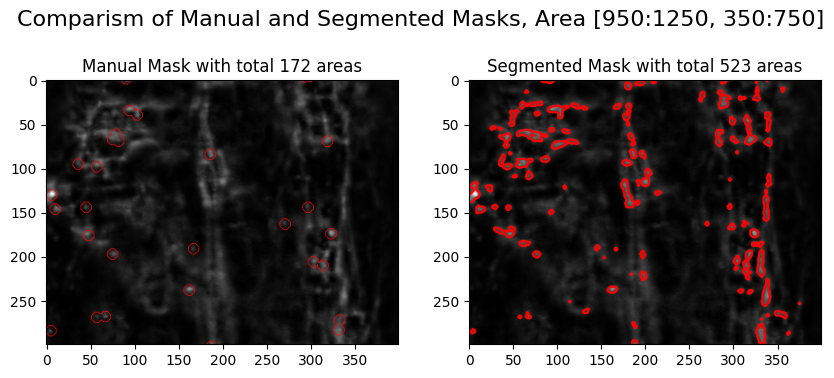

In [47]:
import matplotlib.pyplot as plt
from skimage.measure import label

fig, ax = plt.subplots(1,2, figsize=(10, 5))
fig.suptitle('Comparism of Manual and Segmented Masks, Area [950:1250, 350:750]', fontsize=16, y=0.9)
# ax.imshow(results['clean'][1200:1500,200:900], cmap='Reds', alpha=0.1, linewidth=2)
ax[0].imshow(preprocessed_image[950:1250, 350:750], cmap='gray')
ax[0].contour( mask_areas[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[0].set_title(f'Manual Mask with total {mask_areas.max()} areas')
ax[1].imshow(preprocessed_image[950:1250, 350:750], cmap='gray')
ax[1].contour( segmented_mask_21_15[950:1250, 350:750], [0.8], linewidths=1.5, colors='r')
ax[1].set_title(f'Segmented Mask with total {label(segmented_mask_21_15, connectivity=1).max()} areas')
plt.show()

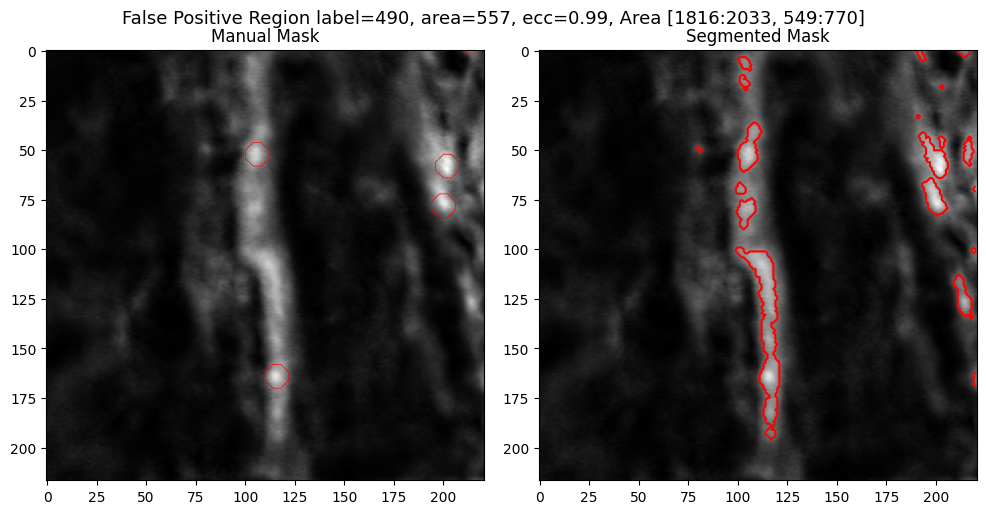

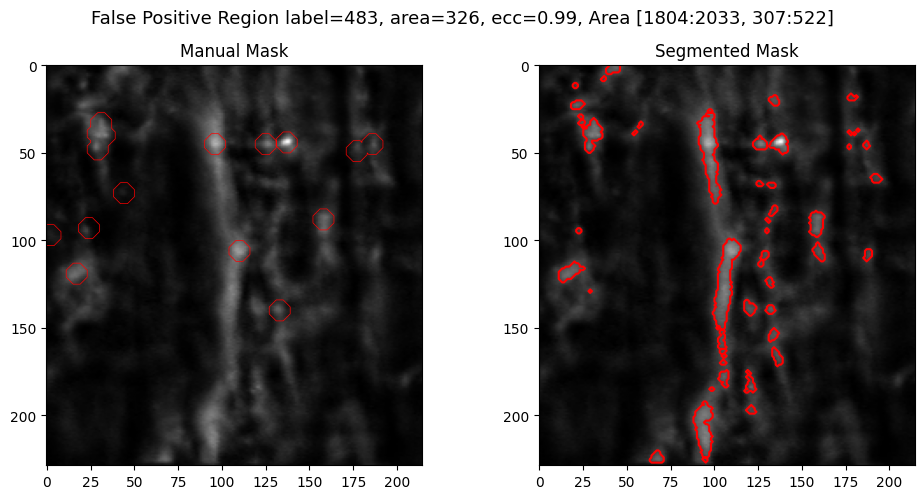

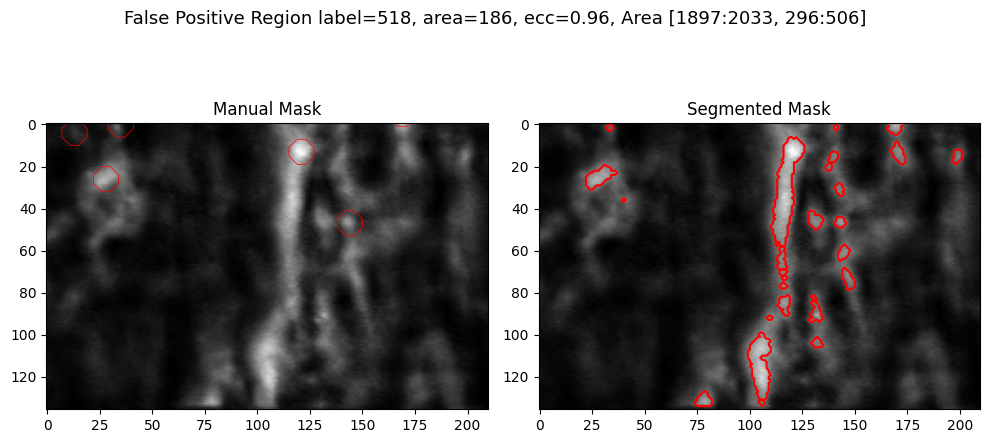

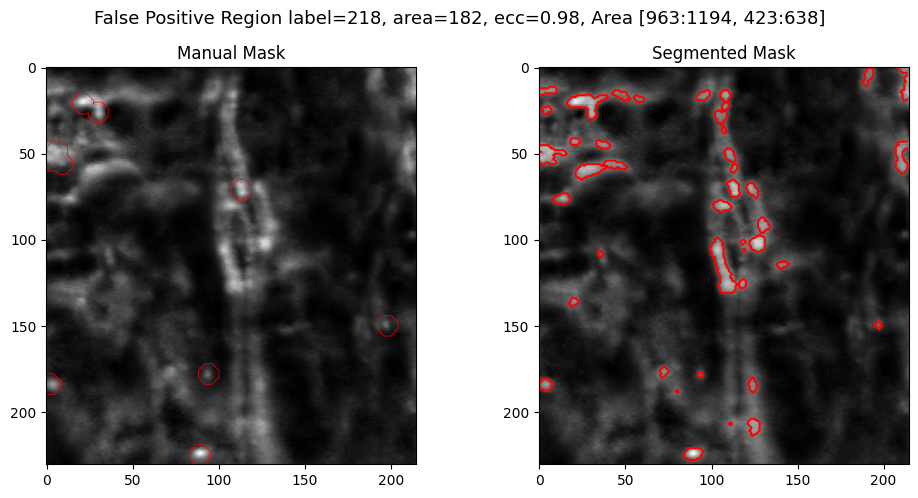

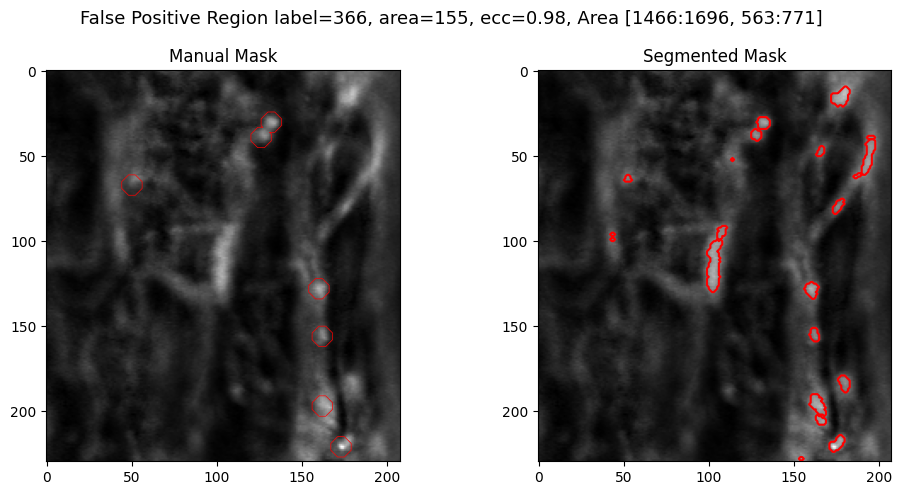

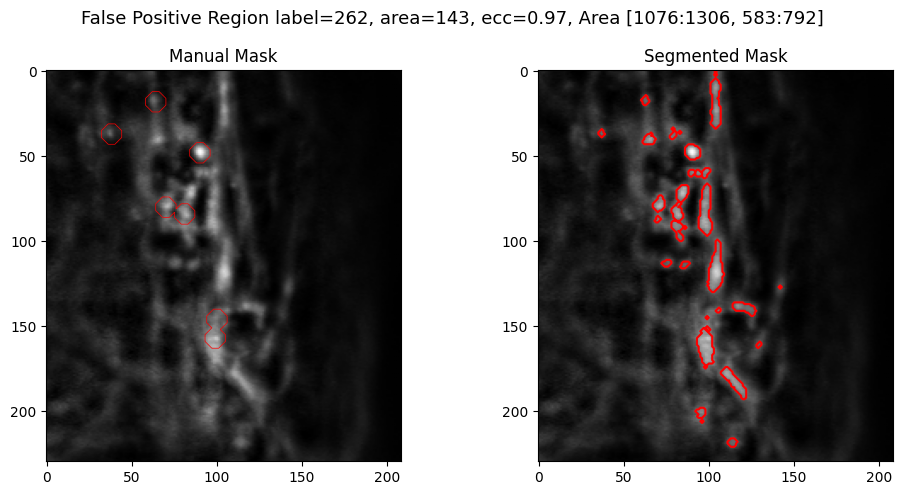

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from scipy.ndimage import distance_transform_edt

# --- 1. Label segmented mask + find false-positive regions ---
seg_labeled = label(segmented_mask_21_15, connectivity=1)
seg_props = regionprops(seg_labeled)

manual_binary = mask_areas > 0
dist_to_manual = distance_transform_edt(~manual_binary)

match_threshold = 10  # pixels, adjust as needed

records = []
for region in seg_props:
    y, x = region.centroid
    dist = dist_to_manual[int(round(y)), int(round(x))]
    records.append({
        'label': region.label,
        'area': region.area,
        'eccentricity': region.eccentricity,
        'bbox': region.bbox,
        'dist_to_manual': dist,
        'is_false_positive': dist > match_threshold
    })

import pandas as pd
df = pd.DataFrame(records)
false_positives = df[df['is_false_positive']].sort_values('area', ascending=False)

# --- 2. For the top N false positives, crop around them and plot manual vs segmented ---
n_examples = 6
pad = 100  # extra context around the region, in pixels

for i, row in false_positives.head(n_examples).iterrows():
    minr, minc, maxr, maxc = row['bbox']
    r0, c0 = max(0, minr - pad), max(0, minc - pad)
    r1, c1 = min(preprocessed_image.shape[0], maxr + pad), min(preprocessed_image.shape[1], maxc + pad)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        f'False Positive Region label={int(row["label"])}, area={int(row["area"])}, '
        f'ecc={row["eccentricity"]:.2f}, Area [{r0}:{r1}, {c0}:{c1}]',
        fontsize=13, y=0.98
    )

    ax[0].imshow(preprocessed_image[r0:r1, c0:c1], cmap='gray')
    ax[0].contour(mask_areas[r0:r1, c0:c1], [0.5], linewidths=0.5, colors='r')
    ax[0].set_title('Manual Mask')

    ax[1].imshow(preprocessed_image[r0:r1, c0:c1], cmap='gray')
    ax[1].contour(segmented_mask_21_15[r0:r1, c0:c1], [0.8], linewidths=1.5, colors='r')
    ax[1].set_title('Segmented Mask')

    plt.tight_layout()
    plt.show()